Loading data

In [1]:
import yfinance as yf
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from itertools import product
import seaborn as sns
from collections import Counter


def load_ticker(ticker, start, end):
    return yf.download(
        ticker, 
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )

In [2]:
date1 = '2004-11-18'
date2 = '2007-11-30'

gld = load_ticker("GLD", date1, date2)
gdx = load_ticker("GDX", date1, date2)

intersection = gld.index.intersection(gdx.index)
gld = gld.loc[intersection]
gdx = gdx.loc[intersection]


gld_open = gld["Open"].squeeze().dropna()
gld_close = gld["Close"].squeeze().dropna()
gdx_open = gdx["Open"].squeeze().dropna()
gdx_close = gdx["Close"].squeeze().dropna()



In [3]:
split_point = gld_open.index[int(len(gld_open.values)*0.8)]
split_point_idx = int(len(gld_open.values)*0.8)




In [ ]:
tickers = yf.download()

Finding the hedge ratio 

In [4]:
x = gdx_close.loc[:split_point].values
y = gld_close.loc[:split_point].values
x = sm.add_constant(x)
result = sm.OLS(y, x).fit()

hedge_ratio = result.params[1]
intercept = result.params[0]

z_score function

In [33]:
def spread_fun(stock1, stock2, hedge):
    spread =  stock1 - hedge*stock2
    return spread

    

def daily_z_score(stock1, stock2, hedge):
    eps = 1e-7
    spread = spread_fun(stock1.values, stock2.values, hedge)
    spread_mean = np.mean(spread)
    spread_std = np.std(spread)

    return (spread[-1]-spread_mean)/(spread_std+eps)

def rolling_z_scores(stock1, stock2, hedge, start, end, window):
    dates = stock1.loc[start:end].index
    
    z_scores = pd.Series(data = np.zeros(len(dates)), index = dates)

    for date in z_scores.index:
        date_idx = stock1.index.get_loc(date)
        
        z_scores[date] = daily_z_score(stock1.iloc[date_idx-window +1: date_idx],
                                       stock2.iloc[date_idx-window +1: date_idx], hedge)
    return z_scores
        



In [18]:
def strategy_p_and_l(stock1, stock2, hedge, z_scores, enter, exit):
    
    p_and_l = pd.Series(data = np.zeros(len(z_scores)), index = z_scores.index)
    stock2 = stock2 * hedge
    enter_long=None
    enter_short=None
    
    
    for date, z_score in z_scores.items():
        if z_score <= - enter and enter_long==None:
            enter_long = date
        elif z_score <= - exit and enter_long != None:
            p_and_l.loc[date] += stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] -= stock2.loc[date] - stock2.shift(1).loc[date]
        elif z_score >= - exit and enter_long != None:
            p_and_l.loc[date] += stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] -= stock2.loc[date] - stock2.shift(1).loc[date]
            enter_long = None
        if z_score >= enter and enter_short == None:
            enter_short = date
        elif z_score >= exit and enter_short != None:
            p_and_l.loc[date] -= stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] += stock2.loc[date] - stock2.shift(1).loc[date]
        elif z_score <= exit and enter_short != None:
            p_and_l.loc[date] -= stock1.loc[date] - stock1.shift(1).loc[date]
            p_and_l.loc[date] += stock2.loc[date] - stock2.shift(1).loc[date]
            enter_short = None    

    return p_and_l

Condtion - training period must start with atleast 20 days of data. No training period must start with atleast 1 window of data 
Task: find the optimal parameters on the training set


In [37]:
training_end = split_point

max_window = 50
windows = np.arange(5, max_window+1, 5)

enter_thresh = np.arange(0.5, 3.1, 0.5)
exit_thresh = np.arange(0.5, 3.1, 0.5)




In [38]:
results = pd.DataFrame(columns = ["Window", "Enter", "Exit", "Sharpe"])
eps =  1e-7
for window, enter, exit in product(windows, enter_thresh, exit_thresh):
    
    training_start = gld_close.index[window]
    
    training_end = split_point
    if(enter > exit):
        z_scores = rolling_z_scores(gld_close, gdx_close, hedge_ratio, training_start, training_end, window)
        p_and_l = strategy_p_and_l(gld_open, gdx_open, hedge_ratio, z_scores, enter, exit)
        percentage_return = np.array(p_and_l.values/(gld_open.shift(1).loc[p_and_l.index]+hedge_ratio*gdx_open.shift(1).loc[p_and_l.index]))
        sharpe = np.sqrt(252)*percentage_return.mean()/(percentage_return.std()+eps)
        results.loc[len(results)] = [window, enter, exit, sharpe]

        

Results seem fine but still needs testing if all of the calulations are done correctly.


In [68]:
# results.iloc[results["Sharpe"].argmax()]
# results.loc[results["Window"]==50]
sorted_results = results.sort_values("Sharpe", ascending = False).reset_index()
best_results = sorted_results[sorted_results["Sharpe"]>1]

window_count = Counter(best_results["Window"])
enter_count = Counter(best_results["Enter"])
exit_count = Counter(best_results["Exit"])
print(window_count)
print(enter_count)
print(exit_count)

Counter({30.0: 11, 35.0: 7, 40.0: 7, 25.0: 7, 45.0: 6, 10.0: 5, 50.0: 4, 20.0: 3, 5.0: 2})
Counter({2.0: 15, 1.5: 15, 1.0: 9, 3.0: 9, 2.5: 4})
Counter({0.5: 24, 1.0: 12, 1.5: 6, 2.5: 6, 2.0: 4})


The top 10 results all feature windows of 40 and above, enter thresholds of 1 and above. The max enter threshold seen is 2, while the max exit thresh seen is 1.5. To further test the optimal parameters, the window interval will be increased to 60 days, the enter interval will be [1:2.5] and 3exit [0.5:2] with more fine increments.

In [30]:
windows = np.arange(40, 56, 5)
enter_thresh = np.arange(1, 2.6, 0.1)
exit_thresh = np.arange(0.5, 2.1, 0.1)


In [34]:
results = pd.DataFrame(columns = ["Window", "Enter", "Exit", "Sharpe"])
eps =  1e-7
for window, enter, exit in product(windows, enter_thresh, exit_thresh):
    
    training_start = gld_close.index[window]
    
    training_end = split_point
    if(enter > exit):
        z_scores = rolling_z_scores(gld_close, gdx_close, hedge_ratio, training_start, training_end, window)
        p_and_l = strategy_p_and_l(gld_open, gdx_open, hedge_ratio, z_scores, enter, exit)
        percentage_return = np.array(p_and_l.values/(gld_open.shift(1).loc[p_and_l.index]+hedge_ratio*gdx_open.shift(1).loc[p_and_l.index]))
        sharpe = np.sqrt(252)*percentage_return.mean()/(percentage_return.std()+eps)
        results.loc[len(results)] = [window, enter, exit, sharpe]


In [35]:
results.sort_values("Sharpe", ascending = False)[:10]

,Window,Enter,Exit,Sharpe
12,40.0,1.1,1.1,2.440084
19,40.0,1.2,1.1,2.425499
218,45.0,1.2,0.9,2.328277
61,40.0,1.6,1.5,2.323669
212,45.0,1.1,1.0,2.310301
216,45.0,1.2,0.7,2.310155
9,40.0,1.1,0.8,2.305185
221,45.0,1.2,1.2,2.268047
213,45.0,1.1,1.1,2.254618
54,40.0,1.6,0.8,2.253874


To figure out the best parameters I will first calculate which window size shows the best average results and then focus on that one 

In [118]:
Sharpe_by_window = results.groupby(["Window"])["Sharpe"].mean()
print(Sharpe_by_window)

Window
40.0    1.334425
45.0    1.502845
50.0    1.516192
55.0    1.228507
Name: Sharpe, dtype: float64


While the best result is shown by a window size of 50, the difference between 45 and 50 seems minimal, to figure out which window is better I will also divide the mean by the std() of the Sharpe ratio to find the more stable choice.

In [119]:
Sharpe_by_window = results.groupby(["Window"])["Sharpe"].mean()/results.groupby(["Window"])["Sharpe"].std()
print(Sharpe_by_window)

Window
40.0    3.494236
45.0    2.904307
50.0    2.091996
55.0    1.653226
Name: Sharpe, dtype: float64


This result shows that even though the 45 window had slightly worse average results, stability-wise its far superior.
To further show that this conclusion is correct I will inspect the heatmaps with both window parameters


In [123]:
results["Enter"] = results["Enter"].round(1)
results["Exit"] = results["Exit"].round(1)

results45 = results.loc[results["Window"]==45]
results50 = results.loc[results["Window"] == 50]
results55 = results.loc[results["Window"] == 55]
results45_pivot = results45.pivot(index = "Enter", columns = "Exit", values = "Sharpe")
results50_pivot = results50.pivot(index = "Enter", columns = "Exit", values = "Sharpe")
results55_pivot = results55.pivot(index = "Enter", columns = "Exit", values = "Sharpe")

window = 45 heatmap

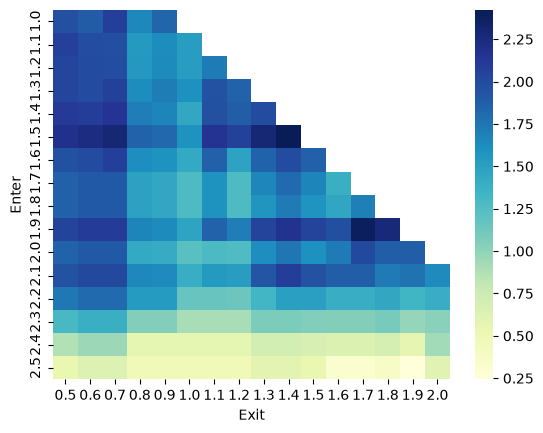

In [121]:
heatmap45 = sns.heatmap(results45_pivot, cmap = "YlGnBu")
plt.show()

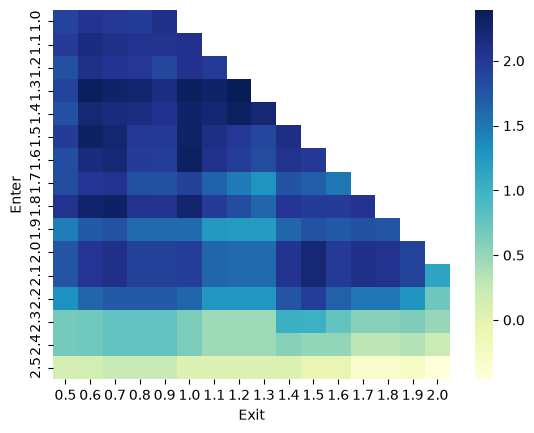

In [122]:
heatmap50 = sns.heatmap(results50_pivot, cmap = "YlGnBu")

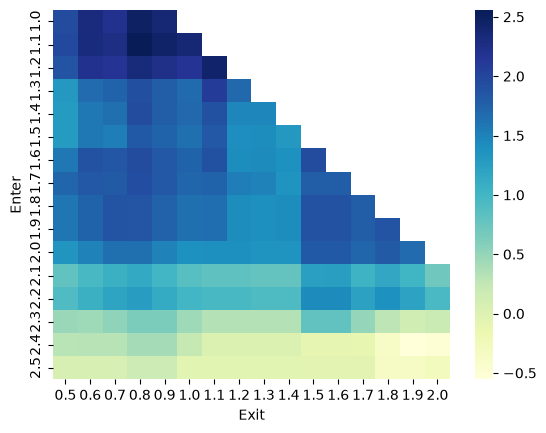

In [124]:
heatmap55 = sns.heatmap(results55_pivot, cmap = "YlGnBu")
plt.show()

<Axes: xlabel='Enter'>

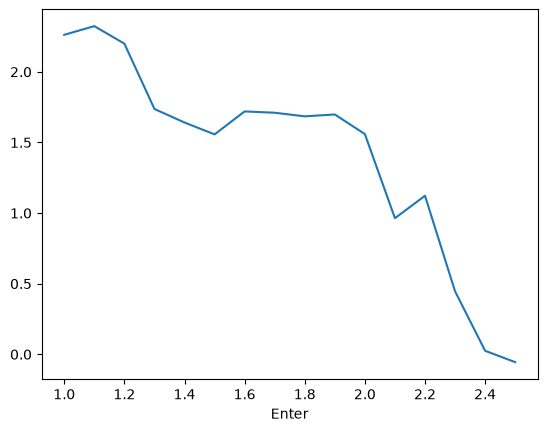

In [135]:
results55_pivot.mean(axis=1).plot()

<Axes: xlabel='Enter'>

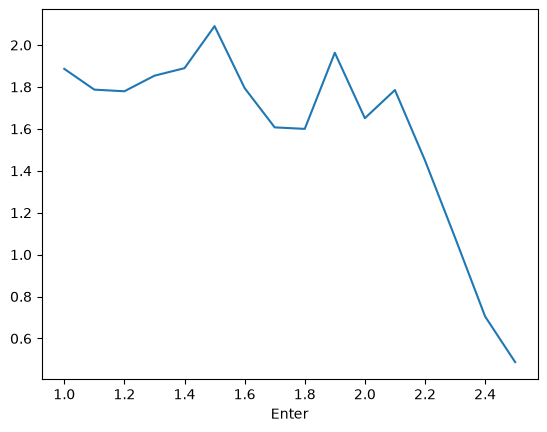

In [136]:
results45_pivot.mean(axis=1).plot()

<Axes: xlabel='Enter'>

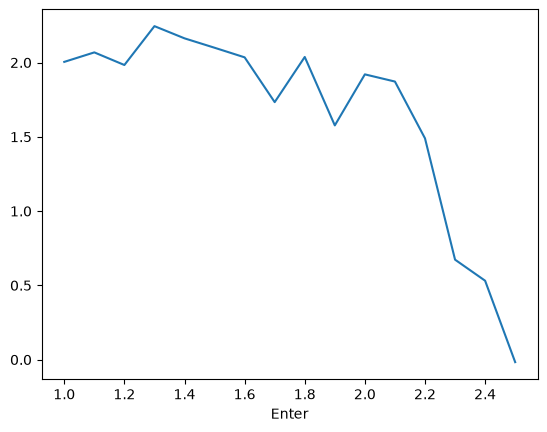

In [137]:
results50_pivot.mean(axis=1).plot()